# ✈️ Cleared for Takeoff?
## A Visual Analysis of U.S. Domestic Flight Delay Patterns (2019–2023)
**Course:** Data Analysis & Data Visualization  
**Author:** Bobby Bagley
**Date:** April 2026  
**Dataset:** Flight Delay & Cancellation Dataset 2019–2023 (BTS via Kaggle)

---

### 🗺️ Notebook Structure
This notebook is organized as a **data story** with four chapters, each answering one central question:

| Chapter | Central Question |
|---|---|
| 1 — Temporal Patterns | *When* do delays peak? |
| 2 — Geographic Patterns | *Where* are delays most severe? |
| 3 — Delay Cause Breakdown | *Why* do flights get delayed? |
| 4 — Airline & Route Analysis | *Who* is most affected? |

Each chapter includes a framing paragraph, one or more visualizations, and an interpretive takeaway.

---
## 0. Environment Setup

In [ ]:
# ── Install any missing packages (run once, then comment out) ──────────────
# Disregard when I'm running in Colab environment. :)
# !pip install altair altair_saver pandas matplotlib seaborn plotly kagglehub

In [ ]:
# ── Core ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import kagglehub # This will connect me to the dataset without needing to attach the file
import os
import warnings
warnings.filterwarnings('ignore')

# ── Matplotlib / Seaborn (heatmaps, bar charts, box plots) ─────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'

# ── Altair (line charts, scatter plots) ..
import altair as alt
alt.data_transformers.enable('default', max_rows=None)  # allow large datasets

# ── Plotly (interactive choropleth map) ..
import plotly.express as px
import plotly.graph_objects as go

# ── Shared style constants ..─────────────
BLUE_PALETTE   = ['#D6E4F0', '#AEC6D8', '#5B9EC9', '#2E75B6', '#1F4E79']
RED_GREEN      = ['#2ecc71', '#f39c12', '#e74c3c']   # on-time → moderate → severe
AIRLINE_COLORS = alt.Color('AIRLINE:N', scale=alt.Scale(scheme='tableau10'))
SEED = 42

print('All imports successful ✅')

All imports successful ✅


---
## 1. Data Loading & Preparation
In this project, I will use **Kaggle** to upload the dataset using the `kagglehub` library. If you are running this notebook, all you need is an API key from a free Kaggle account.

### Loading

In [ ]:
# TODO: DELETE THIS BEFORE SUBMITTING
# KGAT_a2f311914a70452b357b873f653b0434

In [ ]:
# Have your API key ready
kagglehub.login()

In [ ]:
# Find the dataset
path = kagglehub.dataset_download("patrickzel/flight-delay-and-cancellation-dataset-2019-2023")

# Check inside the folder (if it downloaded correctly)
print(os.listdir(path))


Using Colab cache for faster access to the 'flight-delay-and-cancellation-dataset-2019-2023' dataset.
['flights_sample_3m.csv', '.nfs000000008e46eab3000003d1', 'dictionary.html']


In [ ]:
# Download the dataset
df_raw = pd.read_csv(path + '/flights_sample_3m.csv')

# Check your work
df_raw.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


### Preparation

1. Drop cancelled flights or where `DEP_DELAY = NaN`
2. Engineer binary delayed flag ⛳ `IS_DELAYED`. Delayed is $15 minutes\geq$ according to FAA standard
3. Extract the hour of the day from `CRS_DEP_TIME`
4. Engineer weekend feature

In [ ]:
df = df_raw.copy()

# Convert 'FL_DATE' to datetime objects to extract month and day of week
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['MONTH'] = df['FL_DATE'].dt.month
df['DAY_OF_WEEK'] = df['FL_DATE'].dt.dayofweek + 1 # Monday=1, Sunday=7
df['YEAR'] = df['FL_DATE'].dt.year

# Drop rows with no departure delay info (cancelled flights)
df = df.dropna(subset=['DEP_DELAY'])

# Binary delayed flag  (FAA standard: ≥ 15 min)
df['IS_DELAYED']  = (df['DEP_DELAY'] >= 15).astype(int)

# Derived time features
df['HOUR_OF_DAY'] = (df['CRS_DEP_TIME'] // 100).clip(0, 23)
df['IS_WEEKEND']  = df['DAY_OF_WEEK'].isin([6, 7]).astype(int)

MONTH_NAMES = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
DAY_NAMES   = {1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat',7:'Sun'}

df['MONTH_NAME'] = df['MONTH'].map(MONTH_NAMES)
df['DAY_NAME']   = df['DAY_OF_WEEK'].map(DAY_NAMES)

def get_season(m):
    return {12:'Winter',1:'Winter',2:'Winter',
             3:'Spring',4:'Spring',5:'Spring',
             6:'Summer',7:'Summer',8:'Summer',
             9:'Fall',10:'Fall',11:'Fall'}.get(m,'Unknown')
df['SEASON'] = df['MONTH'].map(get_season)

"""
# ── Stratified sample for performance if necassary
SAMPLE_N = 500_000
if len(df) > SAMPLE_N:
    df = df.groupby('IS_DELAYED', group_keys=False).apply(
        lambda x: x.sample(frac=SAMPLE_N/len(df_raw), random_state=SEED)
    ).reset_index(drop=True)

print(f'Working dataset: {df.shape}')
print(f'Delay rate: {df["IS_DELAYED"].mean():.1%}')
"""

'\n# ── Stratified sample for performance if necassary\nSAMPLE_N = 500_000\nif len(df) > SAMPLE_N:\n    df = df.groupby(\'IS_DELAYED\', group_keys=False).apply(\n        lambda x: x.sample(frac=SAMPLE_N/len(df_raw), random_state=SEED)\n    ).reset_index(drop=True)\n\nprint(f\'Working dataset: {df.shape}\')\nprint(f\'Delay rate: {df["IS_DELAYED"].mean():.1%}\')\n'

In [ ]:
# Check your work
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DELAY_DUE_LATE_AIRCRAFT,MONTH,DAY_OF_WEEK,YEAR,IS_DELAYED,HOUR_OF_DAY,IS_WEEKEND,MONTH_NAME,DAY_NAME,SEASON
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,NaN,1,3,2019,0,11,0,Jan,Wed,Winter
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,NaN,11,6,2022,0,21,1,Nov,Sat,Fall
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,NaN,7,5,2022,0,9,0,Jul,Fri,Summer
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,3,1,2023,0,16,0,Mar,Mon,Spring
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,NaN,2,7,2020,0,18,1,Feb,Sun,Winter


In [ ]:
print(df.columns)
print(f'Working dataset: {df.shape}')
print(f'Delay rate: {df["IS_DELAYED"].mean():.1%}')

Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT', 'MONTH', 'DAY_OF_WEEK', 'YEAR', 'IS_DELAYED',
       'HOUR_OF_DAY', 'IS_WEEKEND', 'MONTH_NAME', 'DAY_NAME', 'SEASON'],
      dtype='object')
Working dataset: (2922356, 41)
Delay rate: 18.2%


**Single control panel for all column names.**

In [ ]:
# ── Column name reference
CARRIER_COL    = 'AIRLINE_CODE'     # airline code  (e.g. 'AA', 'DL')
ORIGIN_COL     = 'ORIGIN'           # departure airport (IATA, e.g. 'IAH')
DEST_COL       = 'DEST'             # arrival airport
DISTANCE_COL   = 'DISTANCE'         # flight distance in miles
YEAR_COL       = 'YEAR'

# Delay cause columns
CAUSE_COLS = {
    'Carrier':      'DELAY_DUE_CARRIER',
    'Weather':      'DELAY_DUE_WEATHER',
    'NAS':          'DELAY_DUE_NAS',          # Air traffic control
    'Security':     'DELAY_DUE_SECURITY',
    'Late Aircraft':'DELAY_DUE_LATE_AIRCRAFT',
}
# Keep only cause columns that exist
CAUSE_COLS = {k: v for k, v in CAUSE_COLS.items() if v in df.columns}
print(f'Delay cause columns found: {list(CAUSE_COLS.keys())}')

Delay cause columns found: ['Carrier', 'Weather', 'NAS', 'Security', 'Late Aircraft']


### Summary

In this section we:
* Connected and downloaded the dataset using a user's Kaggle API key.
* Dropped cancelled flights (*where* `DEP_DELAY = NaN` )
* Engineered `IS_DELAYED` binary feature
* Made some quality of life changes to work with time features easier

---
# 📅 Chapter 1 — Temporal Patterns
### *When do delays peak?*

Delays are not random — I suspect they follow strong seasonal, weekly, and daily rhythms. This chapter aims to uncover those rhythms and highlights how the COVID-19 pandemic disrupted patterns we might otherwise take for granted.

### 1.1 Monthly Delay Rate Heatmap (2019–2023)
**Chart type:** Seaborn heatmap  
**Why this chart:** A heatmap lets us read two dimensions at once — month and year — making it easy to spot both seasonal cycles and year-over-year anomalies like the 2020 COVID collapse.

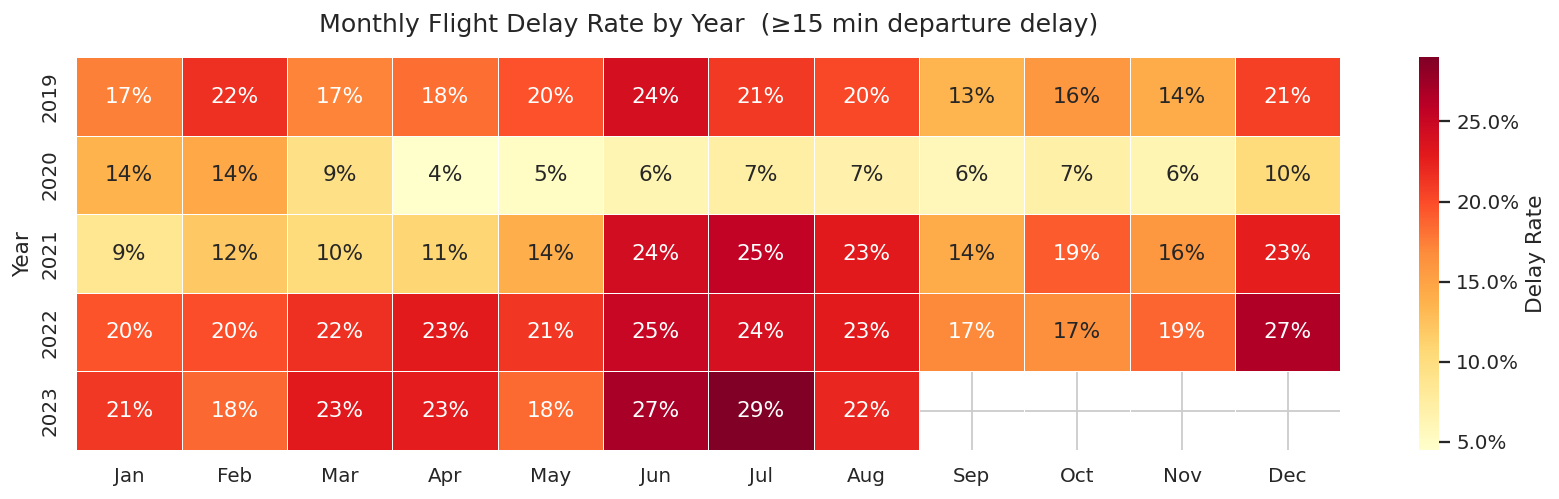

In [ ]:
# ── Aggregate: delay rate by year × month
heatmap_data = (
    df.groupby([YEAR_COL, 'MONTH'])['IS_DELAYED']
    .mean()
    .reset_index()
    .pivot(index=YEAR_COL, columns='MONTH', values='IS_DELAYED')
)
heatmap_data.columns = [MONTH_NAMES[m] for m in heatmap_data.columns]

# ── Plot
fig, ax = plt.subplots(figsize=(13, 4))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0%',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Delay Rate', 'format': mtick.PercentFormatter(xmax=1)}
)

ax.set_title('Monthly Flight Delay Rate by Year  (≥15 min departure delay)', fontsize=14, pad=14)
ax.set_xlabel('')
ax.set_ylabel('Year')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()



#### Observations: Monthly Delay Rate

The first thing that jumps out is Summer (June - August) is consistently high. This is obvious due to the high amount of travel during this time given the weather and school breaks 😎.

Next we see the winter holiday delays heat up from November to January which is in line with Thanksgiving, Christmas and the other major holidays in that time 🎄.

Lastly, we see a major 'cooling' 🧊 affect in the year 2020 when the COVID-19 pandemic 🦠 began. We see an instant drop starting in January (COVID became a major concern December 2019 when the outbreak in Wuhan was discovered). Then, in **March 2020**, there is a major decrease in delays which coincides with when it was characterized as a *global pandemic* 🌐.

### 1.2 Delay Rate by Hour of Day  *(Altair)*
**Chart type:** Altair line chart with confidence band  
**Why this chart:** A line chart is a good choice for a continuous time x.

In [ ]:
# ── Aggregate: mean delay rate + std error by hour ─────────────────────────
hour_agg = (
    df.groupby('HOUR_OF_DAY')['IS_DELAYED']
    .agg(delay_rate='mean', count='count')
    .reset_index()
)

# ± 1 std dev band — stays visible even at high sample sizes
hour_agg['se']    = np.sqrt(hour_agg['delay_rate'] * (1 - hour_agg['delay_rate']) / hour_agg['count'])
hour_agg['ci_lo'] = (hour_agg['delay_rate'] - hour_agg['se']).clip(0, 1)   # ±1 SD instead of 1.96
hour_agg['ci_hi'] = (hour_agg['delay_rate'] + hour_agg['se']).clip(0, 1)

# ── Hover selection — this is what makes tooltips work on line charts ───────
# Think of it like a magnet: it snaps the tooltip to the nearest data point
# as your cursor moves across the chart
hover = alt.selection_point(
    on='mouseover',
    nearest=True,
    fields=['HOUR_OF_DAY'],
    empty=False
)

base = alt.Chart(hour_agg).encode(
    x=alt.X('HOUR_OF_DAY:Q',
             axis=alt.Axis(title='Scheduled Departure Hour', tickCount=24)),
)

band = base.mark_area(opacity=0.2, color='#2E75B6').encode(
    y=alt.Y('ci_lo:Q', axis=alt.Axis(format='%', title='Delay Rate (≥15 min)')),
    y2='ci_hi:Q'
)

line = base.mark_line(color='#2E75B6', strokeWidth=2.5).encode(
    y=alt.Y('delay_rate:Q', axis=alt.Axis(format='%')),
)

points = base.mark_circle(color='#1F4E79', size=40).encode(
    y='delay_rate:Q'
)

# ── Transparent hover layer — invisible but captures mouse events ───────────
tooltip_layer = base.mark_point(opacity=0, size=200).encode(
    y=alt.Y('delay_rate:Q'),
    tooltip=[
        alt.Tooltip('HOUR_OF_DAY:Q', title='Hour'),
        alt.Tooltip('delay_rate:Q',  title='Delay Rate', format='.1%'),
        alt.Tooltip('count:Q',       title='Flights',    format=','),
    ]
).add_params(hover)

chart_hour = (
    (band + line + points + tooltip_layer)
    .properties(
        title='Flight Delay Rate by Scheduled Departure Hour',
        width=680, height=280
    )
    .configure_title(fontSize=15, anchor='start')
    .configure_axis(labelFontSize=11, titleFontSize=12)
)

chart_hour

alt.LayerChart(...)

#### Observations: Delay Rate by Hour of Day
Here we zoom in to view the hour at which there are delays. Each point on the line represents the average delay rate at each hour of the day.
* **Lowest Delay rate**: 0500 @ 7.3% of flights
* **Highest Delay rate**: 2100 @ 28.3% of flights

There is a linear, positive trend starting at 0700 where the delays increase throughout the day. It indicates that there could be some sort of domino effect going on: If there's a delay earlier in the day, it throws off other subsequent flights.

<u>One thing to note</u>: The confidence band starts at 0000 but disappears at 0500. This looks like a programming error, but it's working correctly. It's just statistically invisible. Red-eye hours (0–4) have very few flights, so the uncertainty is wide and visible. Daytime hours have tens of thousands of flights, making the 95% CI so tight it renders as a hairline.



### 1.3 Delay Rate by Day of Week
**Chart type:** Seaborn bar chart  
**Why this chart:** Only 7 categories — a simple bar chart communicates the ranking immediately without any visual noise.

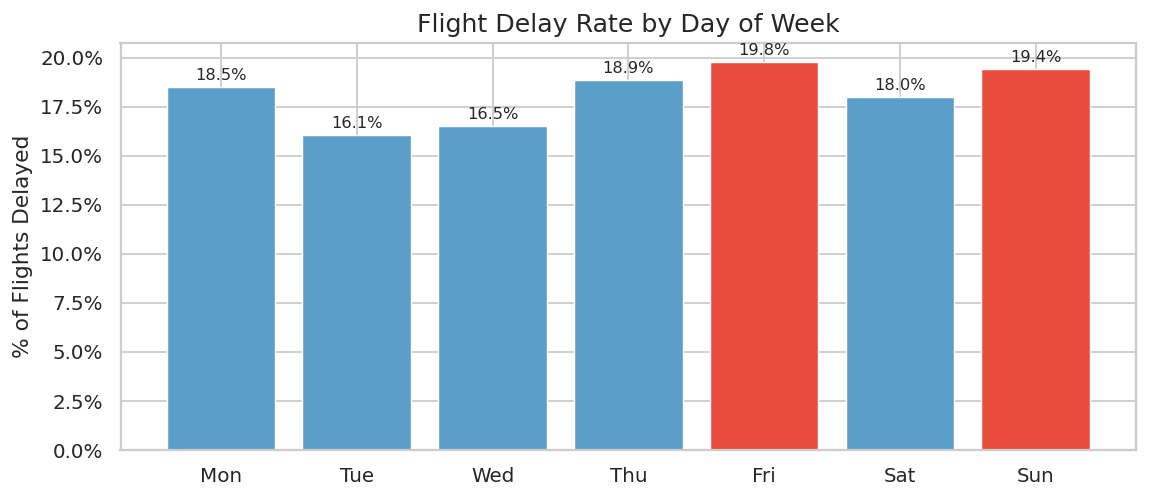

In [ ]:
# ── Aggregate
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_agg   = (
    df.groupby('DAY_NAME')['IS_DELAYED']
    .mean()
    .reindex(day_order)
    .reset_index()
)

# ── Color: highlight Friday & Sunday as worst days .──────
colors = ['#e74c3c' if d in ['Fri','Sun'] else '#5B9EC9' for d in day_order]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(day_agg['DAY_NAME'], day_agg['IS_DELAYED'], color=colors, edgecolor='white', linewidth=0.8)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Flight Delay Rate by Day of Week', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('% of Flights Delayed')

# Annotate bar tops
for bar, val in zip(bars, day_agg['IS_DELAYED']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{val:.1%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

#### Observation: Flight Delay by Day of Week
The rate of delays by day is relatively flat. There is a 3.7% difference from the lowest and highest day, Tuesday and Friday respectively.

## Chapter 1 Summary
📅 Temporal patterns in flight delays are anything but random. At the monthly level, two seasonal peaks dominate the five-year record: summer (June–August), driven by peak leisure travel and school breaks, and the winter holiday corridor (November–January), aligned with Thanksgiving and Christmas demand surges. The most striking feature of the heatmap, however, is 2020 — where delay rates collapse nearly to zero beginning in March, the month COVID-19 was declared a global pandemic. The drop is visible as early as January 2020, consistent with initial outbreak reports in late 2019, and marks a clean structural break from every seasonal pattern seen in the surrounding years.

🌞 At the day-of-week level, the story is comparatively quiet. Delay rates are remarkably stable across the week, with only a 3.7 percentage point spread separating the best day (Tuesday) from the worst (Friday). While Friday's end-of-workweek travel volume likely contributes to its elevated rate, the narrow overall range suggests that time of day and time of year are far stronger predictors of delay risk than day of week alone.

⌚ Zooming into the hour of day, the data reveals a strong positive trend beginning at 5:00 AM, where the daily minimum delay rate sits at just 7.3%. From there, delays climb steadily and nearly linearly throughout the day, peaking at 9:00 PM with 28.3% of flights delayed. This pattern is consistent with a compounding "domino effect" — an early morning delay propagates downstream, disrupting aircraft rotations and crew schedules across subsequent flights for the rest of the day. The practical takeaway is clear: earlier departures are reliably lower risk.



---
# 🗺️ Chapter 2 — Geographic Patterns
### *Where are delays most severe?*

Delay risk is not uniform across the country. Geography, airport size, and hub structure all play a role. This chapter maps the national landscape of delays and zooms in on Houston's two airports.

### 2.1 Average Departure Delay by Origin Airport — Interactive Map
**Chart type:** Plotly bubble map  
**Why this chart:** A geographic map instantly communicates spatial patterns that a bar chart cannot. Bubble size encodes flight volume so we can distinguish high-traffic chronic delay hubs from low-volume outliers.

In [ ]:
airports_raw = pd.read_csv('https://raw.githubusercontent.com/datasets/airport-codes/master/data/airport-codes.csv')

# ── Filter to US airports and inspect what we're working with ───────────────
us_airports = airports_raw[airports_raw['iso_country'] == 'US'].copy()

print(f"Total US airports in geo file: {len(us_airports)}")
print(f"\nSample coordinates values:\n{us_airports['coordinates'].dropna().head(5).tolist()}")
print(f"\nSample iata_code values:\n{us_airports['iata_code'].dropna().head(10).tolist()}")
print(f"\nSample local_code values:\n{us_airports['local_code'].dropna().head(10).tolist()}")

Total US airports in geo file: 32485

Sample coordinates values:
['40.070985, -74.933689', '38.704022, -101.473911', '59.947733, -151.692524', '34.86479949951172, -86.77030181884766', '59.093287, -156.456699']

Sample iata_code values:
['OCA', 'CSE', 'CUS', 'JCY', 'WLR', 'NUP', 'PTC', 'ICY', 'PPV', 'KKK']

Sample local_code values:
['00A', '00AA', '00AK', '00AL', '00AN', '00AS', '00AZ', '00CA', '00CL', '00CN']


In [ ]:
# ── Filter to US airports with valid IATA codes and coordinates ─────────────
airports_geo = (
    us_airports[['iata_code', 'coordinates']]
    .dropna(subset=['iata_code', 'coordinates'])
    .copy()
)

# ── Split "lat, lon" string into two numeric columns ────────────────────────
airports_geo[['lat', 'lon']] = (
    airports_geo['coordinates']
    .str.split(',', expand=True)
    .astype(float)
)

print(f"Airports with valid coords: {len(airports_geo)}")
print(airports_geo[['iata_code', 'lat', 'lon']].head())

# ── Merge with flight delay aggregation ─────────────────────────────────────
airport_agg = (
    df.groupby(ORIGIN_COL)
    .agg(
        delay_rate  =('IS_DELAYED', 'mean'),
        flight_count=('IS_DELAYED', 'count')
    )
    .query('flight_count > 500')
    .reset_index()
)

airport_agg = airport_agg.merge(
    airports_geo[['iata_code', 'lat', 'lon']],
    left_on  = ORIGIN_COL,
    right_on = 'iata_code',
    how      = 'left'
).dropna(subset=['lat', 'lon'])

print(f"\nAirports successfully mapped: {len(airport_agg)}")
print(airport_agg[[ORIGIN_COL, 'lat', 'lon', 'delay_rate', 'flight_count']].head(10))

Airports with valid coords: 2035
     iata_code        lat         lon
410        OCA  25.325399  -80.274803
633        CSE  38.851918 -106.928341
890        CUS  31.823898 -107.629924
987        JCY  30.251801  -98.622498
1287       WLR  55.601299 -131.636993

Airports successfully mapped: 237
  ORIGIN        lat         lon  delay_rate  flight_count
0    ABE  40.651773  -75.442797    0.141916          1973
1    ABI  32.411301  -99.681900    0.149886           874
2    ABQ  35.039976 -106.608925    0.163518          9051
3    ACK  41.253101  -70.060204    0.248252           572
4    ACT  31.611300  -97.230499    0.138686           685
5    ACV  40.978101 -124.109000    0.134496           803
6    ACY  39.456201  -74.577511    0.155725          1310
7    AEX  31.325828  -92.546702    0.123596          1157
8    AGS  33.369900  -81.964500    0.149944          1794
9    ALB  42.748299  -73.801697    0.166631          4693


In [ ]:
import plotly.graph_objects as go

# ── Build hover text ────────────────────────────────────────────────────────
airport_agg['text'] = (
    '<b>' + airport_agg[ORIGIN_COL] + '</b><br>' +
    'Delay Rate: ' + (airport_agg['delay_rate'] * 100).round(1).astype(str) + '%<br>' +
    'Flights: ' + airport_agg['flight_count'].apply(lambda x: f'{x:,}')
)

# ── Scale bubble size proportionally to flight volume ──────────────────────
size_scaled = (
    (airport_agg['flight_count'] - airport_agg['flight_count'].min()) /
    (airport_agg['flight_count'].max() - airport_agg['flight_count'].min())
) * 40 + 6   # range: 6 (smallest) → 46 (largest)

# ── Figure ──────────────────────────────────────────────────────────────────
fig = go.Figure(data=go.Scattergeo(
    locationmode = 'USA-states',
    lon          = airport_agg['lon'],
    lat          = airport_agg['lat'],
    text         = airport_agg['text'],
    mode         = 'markers',
    marker = dict(
        size           = size_scaled,
        opacity        = 0.8,
        autocolorscale = False,
        line           = dict(width=0.5, color='white'),
        colorscale     = 'YlOrRd',
        cmin           = airport_agg['delay_rate'].min(),
        color          = airport_agg['delay_rate'],
        cmax           = airport_agg['delay_rate'].max(),
        colorbar       = dict(
            title      = dict(text='Delay Rate'),
            tickformat = '.0%'
        )
    ),
    hovertemplate = '%{text}<extra></extra>'
))

fig.update_layout(
    title = 'Departure Delay Rate by Origin Airport (2019–2023)<br>'
            '<sup>Bubble size = flight volume | Color = delay rate (yellow = low, red = high)</sup>',
    geo = dict(
        scope           = 'usa',
        projection_type = 'albers usa',
        showland        = True,
        landcolor       = 'rgb(240, 240, 240)',
        subunitcolor    = 'rgb(200, 200, 200)',
        countrycolor    = 'rgb(200, 200, 200)',
        showlakes       = True,
        lakecolor       = 'rgb(255, 255, 255)',
        subunitwidth    = 0.5
    )
)

fig.show()

#### Observations: Average Departure Delay by Origin Airport
There is a lot going on in this map. Bubble size indicates the volume of traffic in an airport while the color is the delay rate ( 🟨lower delay 🟥higher delay). What I do notice is that there is no clear correlation of the size of the bubble to the color of the bubble. Meaning, just because an airport has a ton of traffic, does not mean it's delay rate will be high.

### 2.2 Top 20 Most-Delayed Routes
**Chart type:** Horizontal bar chart  
**Why this chart:** Ranking is best communicated horizontally when labels are long, so the route names remain readable without rotation.

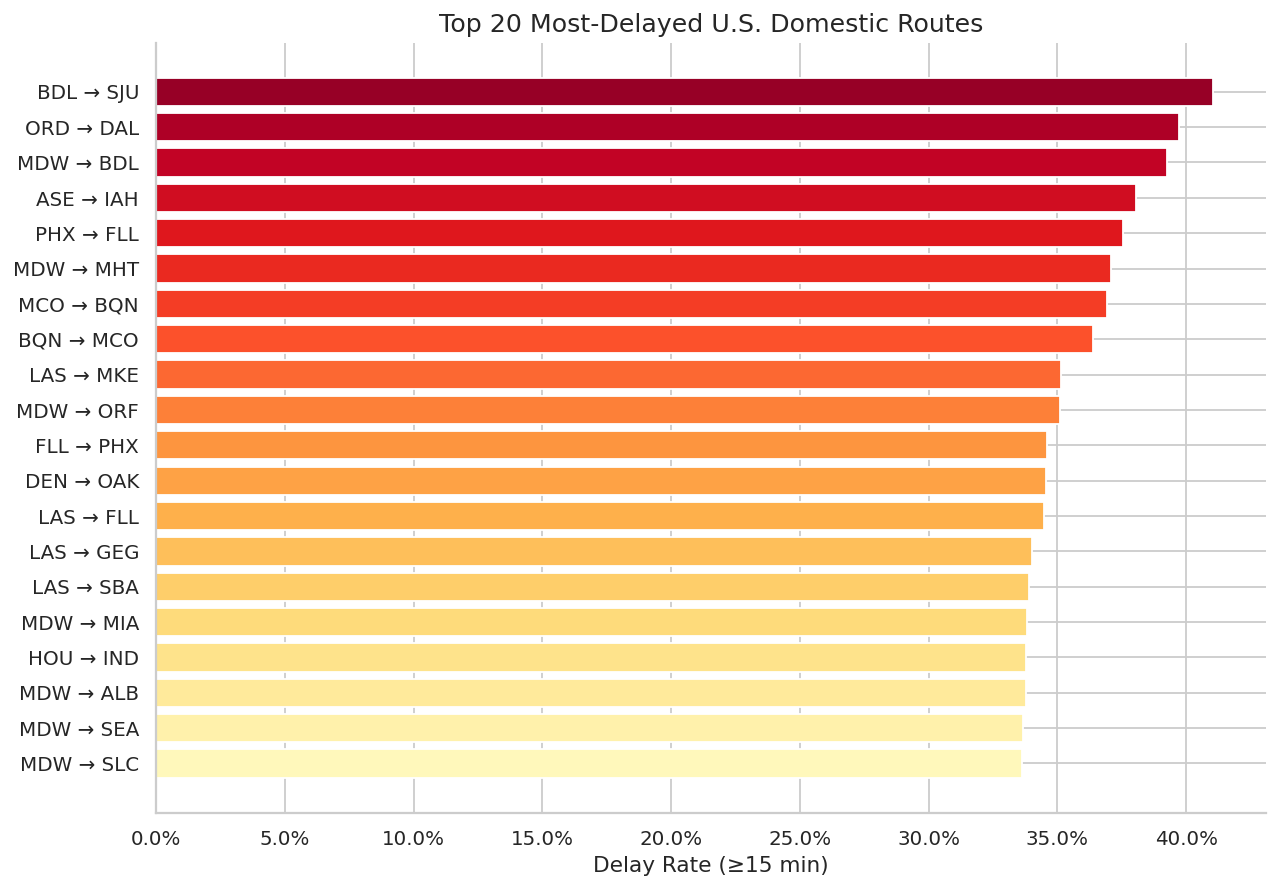

In [ ]:
# ── Aggregate by route (origin → destination) .───────────
df['ROUTE'] = df[ORIGIN_COL] + ' → ' + df[DEST_COL]

route_agg = (
    df.groupby('ROUTE')
    .agg(delay_rate=('IS_DELAYED', 'mean'), count=('IS_DELAYED', 'count'))
    .query('count > 200')         # filter low-volume routes
    .sort_values('delay_rate', ascending=False)
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette('YlOrRd_r', len(route_agg))[::-1]
ax.barh(route_agg['ROUTE'][::-1], route_agg['delay_rate'][::-1],
        color=palette, edgecolor='white')

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Top 20 Most-Delayed U.S. Domestic Routes', fontsize=14)
ax.set_xlabel('Delay Rate (≥15 min)')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

#### Observations: Top 20 Most-Delayed Routes

| Rank | Route | Origin | Destination |
|------|-------|--------|-------------|
| 1 | BDL → SJU | Bradley Intl (Hartford, CT) | Luis Muñoz Marín Intl (San Juan, PR) |
| 2 | ORD → DAL | O'Hare Intl (Chicago, IL) | Love Field (Dallas, TX) |
| 3 | MDW → BDL | Midway Intl (Chicago, IL) | Bradley Intl (Hartford, CT) |
| 4 | ASE → IAH | Aspen/Pitkin County (Aspen, CO) | Bush Intercontinental (Houston, TX) |
| 5 | PHX → FLL | Sky Harbor Intl (Phoenix, AZ) | Fort Lauderdale-Hollywood Intl (Fort Lauderdale, FL) |
| 6 | MDW → MHT | Midway Intl (Chicago, IL) | Manchester-Boston Regional (Manchester, NH) |
| 7 | MCO → BQN | Orlando Intl (Orlando, FL) | Rafael Hernández (Aguadilla, PR) |
| 8 | BQN → MCO | Rafael Hernández (Aguadilla, PR) | Orlando Intl (Orlando, FL) |
| 9 | LAS → MKE | Harry Reid Intl (Las Vegas, NV) | Mitchell Intl (Milwaukee, WI) |
| 10 | MDW → ORF | Midway Intl (Chicago, IL) | Norfolk Intl (Norfolk, VA) |
| 11 | FLL → PHX | Fort Lauderdale-Hollywood Intl (Fort Lauderdale, FL) | Sky Harbor Intl (Phoenix, AZ) |
| 12 | DEN → OAK | Denver Intl (Denver, CO) | Oakland Intl (Oakland, CA) |
| 13 | LAS → FLL | Harry Reid Intl (Las Vegas, NV) | Fort Lauderdale-Hollywood Intl (Fort Lauderdale, FL) |
| 14 | LAS → GEG | Harry Reid Intl (Las Vegas, NV) | Spokane Intl (Spokane, WA) |
| 15 | LAS → SBA | Harry Reid Intl (Las Vegas, NV) | Santa Barbara Airport (Santa Barbara, CA) |
| 16 | MDW → MIA | Midway Intl (Chicago, IL) | Miami Intl (Miami, FL) |
| 17 | HOU → IND | Hobby Airport (Houston, TX) | Indianapolis Intl (Indianapolis, IN) |
| 18 | MDW → ALB | Midway Intl (Chicago, IL) | Albany Intl (Albany, NY) |
| 19 | MDW → SEA | Midway Intl (Chicago, IL) | Seattle-Tacoma Intl (Seattle, WA) |
| 20 | MDW → SLC | Midway Intl (Chicago, IL) | Salt Lake City Intl (Salt Lake City, UT) |

> **Notable pattern:** Chicago Midway (MDW) appears as the origin on 7 of the 20 most-delayed routes, making it the single largest contributor to this list.

### 2.3 Houston Spotlight — IAH vs. HOU vs. National Average
**Chart type:** Annotated bar chart  
**Why this chart:** Benchmarking local airports against the national average gives the audience a personal anchor — most viewers will have flown through one of these two airports.

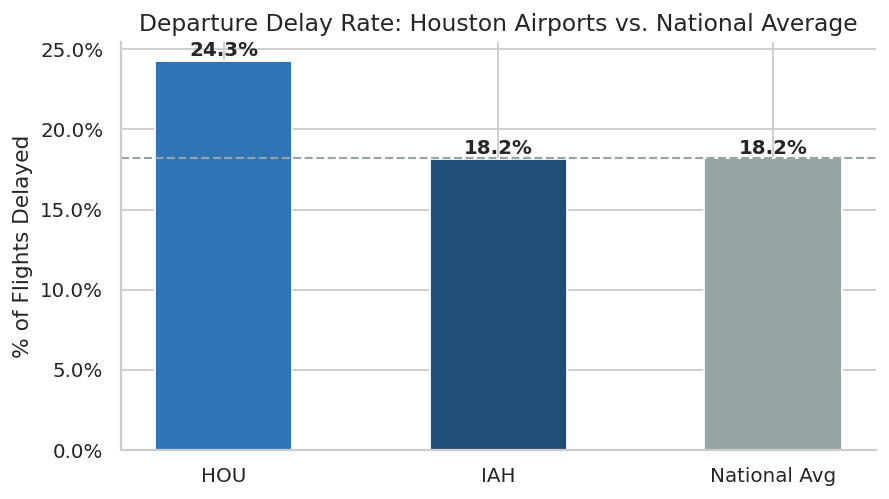

In [ ]:
# ── Build comparison ...─
national_avg = df['IS_DELAYED'].mean()

houston_airports = ['IAH', 'HOU']
houston_data = (
    df[df[ORIGIN_COL].isin(houston_airports)]
    .groupby(ORIGIN_COL)['IS_DELAYED']
    .mean()
    .reset_index()
    .rename(columns={ORIGIN_COL: 'Airport', 'IS_DELAYED': 'Delay Rate'})
)
national_row = pd.DataFrame({'Airport': ['National Avg'], 'Delay Rate': [national_avg]})
compare_df   = pd.concat([houston_data, national_row], ignore_index=True)
compare_df['Color'] = compare_df['Airport'].map({
    'IAH': '#1F4E79', 'HOU': '#2E75B6', 'National Avg': '#95a5a6'
})

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(compare_df['Airport'], compare_df['Delay Rate'],
              color=compare_df['Color'], edgecolor='white', width=0.5)

# National average reference line
ax.axhline(national_avg, color='#95a5a6', linestyle='--', linewidth=1.2, label='National Avg')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Departure Delay Rate: Houston Airports vs. National Average', fontsize=13)
ax.set_ylabel('% of Flights Delayed')

for bar, val in zip(bars, compare_df['Delay Rate']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

#### Observations: Houston Spotlight
This is an interesting and relevant visualization for us as it takes a focused look at the performance of our 2 major airports here in Houston. We see that **HOU** Hobby, the smaller airport, has a staggering 24.3% delay rate. It's one of the worst in the country. Meanwhile, **IAH** the largest airport in the Houston area is equivalent to the national average at 18.2% delay rate. Which airport will you fly out of next time? 🛬

### Chapter 2 Summary
Geography shapes delay risk in ways that defy simple assumptions. Across 237 mapped U.S. airports, the most immediate takeaway is that airport size is not a reliable predictor of delay rate — large high-traffic hubs and smaller regional airports often perform similarly, suggesting that operational efficiency and geographic exposure matter far more than volume alone. When zooming into the route level, however, a clear concentration emerges: Chicago Midway (MDW) alone accounts for 7 of the 20 most-delayed routes in the country, with Las Vegas (LAS) a distant second at four appearances. Rather than delay risk being evenly distributed across the network, it clusters heavily around specific origin airports with systemic operational challenges. For Houston travelers, this plays out in a particularly striking local example — Hobby Airport (HOU) posts a 24.3% delay rate, one of the worst in the country, while Bush Intercontinental (IAH) sits right at the national average of 18.2%. The takeaway from Chapter 2 is clear: where you fly from matters as much as when you fly — and not always in the direction you'd expect.

---
# 🔍 Chapter 3 — Delay Cause Breakdown
### *Why do flights get delayed?*

Not all delays are created equal. A weather delay is outside anyone's control — a carrier or late-aircraft delay signals an operational failure the airline could potentially fix. This chapter decomposes delay causes over time and by airline.

### 3.1 Delay Cause Composition by Year — Stacked Bar (100%)
**Chart type:** 100% stacked bar chart  
**Why this chart:** A 100% stacked bar normalizes for total flight volume, letting us compare the *mix* of causes across years rather than raw totals.

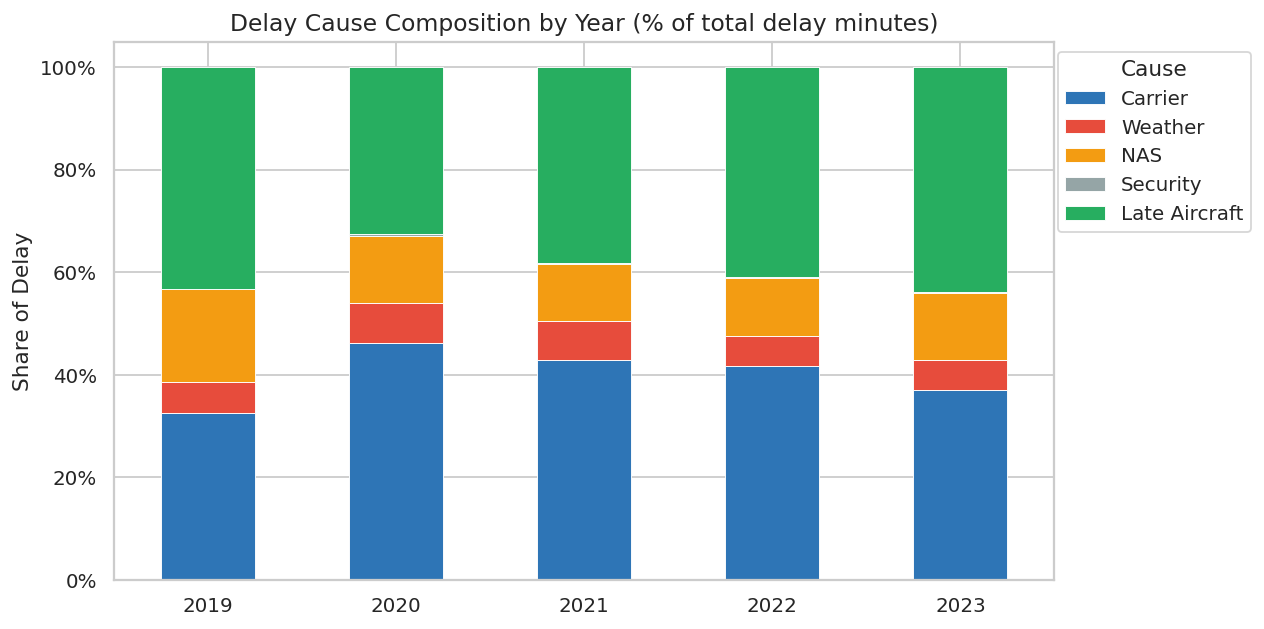

In [ ]:
# ── Aggregate cause totals by year
# Only rows where a delay actually occurred
df_delayed = df[df['IS_DELAYED'] == 1]

cause_year = (
    df_delayed.groupby(YEAR_COL)[list(CAUSE_COLS.values())]
    .sum()
    .rename(columns={v: k for k, v in CAUSE_COLS.items()})
)

# Normalize to 100%
cause_year_pct = cause_year.div(cause_year.sum(axis=1), axis=0)

# ── Plot
cause_colors = ['#2E75B6', '#e74c3c', '#f39c12', '#95a5a6', '#27ae60']

fig, ax = plt.subplots(figsize=(10, 5))
cause_year_pct.plot(
    kind='bar', stacked=True, ax=ax,
    color=cause_colors, edgecolor='white', linewidth=0.5
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Delay Cause Composition by Year (% of total delay minutes)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Share of Delay')
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='upper right', bbox_to_anchor=(1.22, 1), title='Cause')

plt.tight_layout()
plt.show()

In [ ]:
# Put the share of delay by year in a table
cause_year_pct.round(2)


,Carrier,Weather,NAS,Security,Late Aircraft
YEAR,,,,,
2019,0.32,0.06,0.18,0.0,0.43
2020,0.46,0.08,0.13,0.0,0.33
2021,0.43,0.08,0.11,0.0,0.38
2022,0.42,0.06,0.11,0.0,0.41
2023,0.37,0.06,0.13,0.0,0.44


#### Observations: Delay cause by Year
In this stacked bar chart, we explore the share of each type of delay per year. There is also a DataFrame accompanying below to provide exact values.

What we see here is that the two prevailing causes of delay are `Carrier` and `Late Aircraft`. Surprisingly, `Weather` is the least common if you exclude `Security`. One would think that weather would delay more flights, but in reality, delays due to circumstances within the airline's control are more common. This category includes issues such as maintenance or crew problems, aircraft cleaning, baggage loading, fueling, and other operational factors managed by the carrier.

### 3.2 Delay Cause by Airline — Grouped Bar
**Chart type:** Grouped bar chart  
**Why this chart:** Grouping by airline and cause side-by-side reveals which carriers have a disproportionate "late aircraft" problem — the most controllable (and embarrassing) delay type.

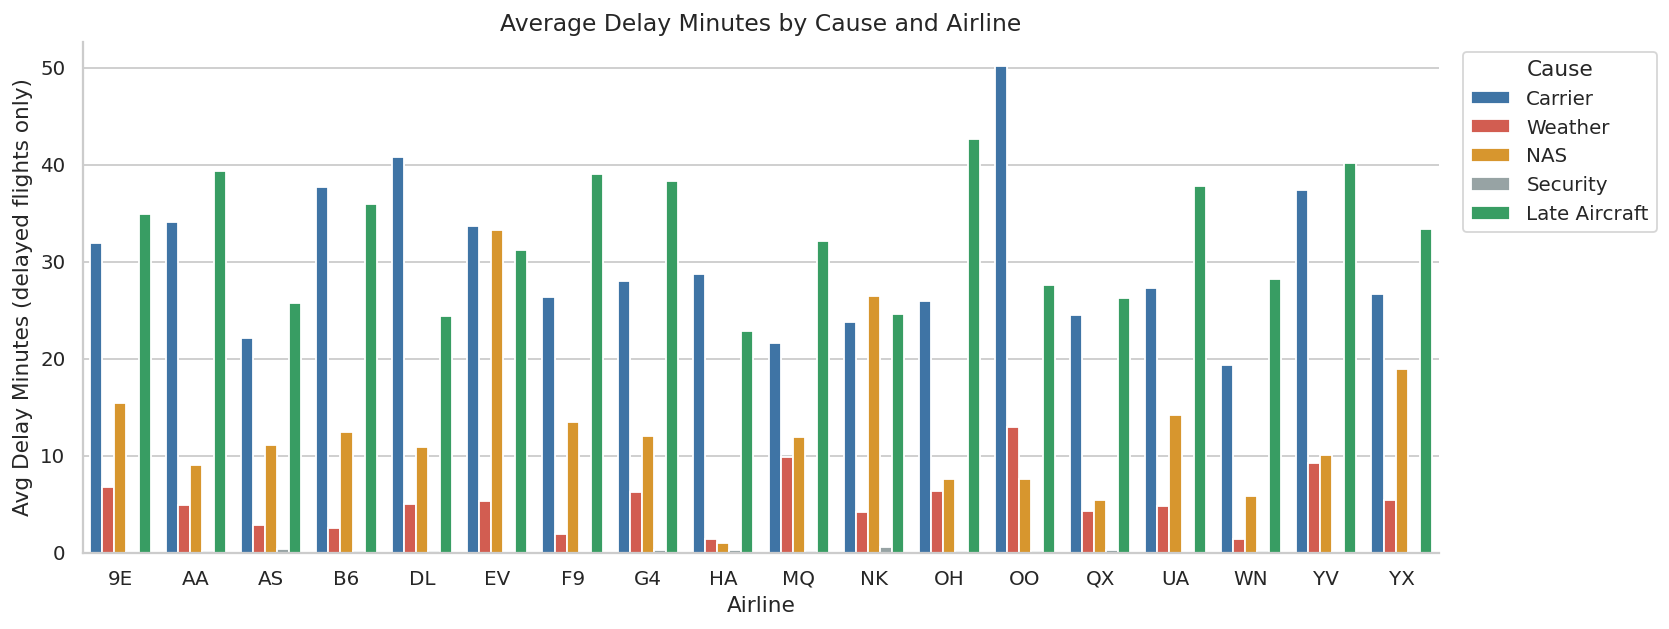

In [ ]:
# ── Aggregate cause totals by airline
cause_airline = (
    df_delayed.groupby(CARRIER_COL)[list(CAUSE_COLS.values())]
    .mean()
    .rename(columns={v: k for k, v in CAUSE_COLS.items()})
    .reset_index()
    .melt(id_vars=CARRIER_COL, var_name='Cause', value_name='Avg Delay Minutes')
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(
    data=cause_airline,
    x=CARRIER_COL, y='Avg Delay Minutes', hue='Cause',
    palette=dict(zip(CAUSE_COLS.keys(), cause_colors)),
    ax=ax
)

ax.set_title('Average Delay Minutes by Cause and Airline', fontsize=13)
ax.set_xlabel('Airline')
ax.set_ylabel('Avg Delay Minutes (delayed flights only)')
ax.legend(title='Cause', bbox_to_anchor=(1.01, 1))
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

Below are the corresponding names for each carrier.
| Code | Airline |
|------|---------|
| 9E | Endeavor Air |
| AA | American Airlines |
| AS | Alaska Airlines |
| B6 | JetBlue Airways |
| DL | Delta Air Lines |
| EV | ExpressJet Airlines |
| F9 | Frontier Airlines |
| G4 | Allegiant Air |
| HA | Hawaiian Airlines |
| MQ | Envoy Air (American Eagle) |
| NK | Spirit Airlines |
| OH | PSA Airlines |
| OO | SkyWest Airlines |
| QX | Horizon Air |
| UA | United Airlines |
| WN | Southwest Airlines |
| YV | Mesa Airlines |
| YX | Republic Airways |

#### Observations: Delay Caused by Airline
Across all carriers, one pattern is super clear: Late Aircraft delays (green) are the dominant cause of delay length for virtually every airline. This is operationally significant because late aircraft delays are largely controllable; they occur when an incoming plane arrives late, leaving no aircraft available for the next scheduled departure. Unlike weather, this is a failure of scheduling and fleet management rather than an external force.

Weather (red) and Security (gray) contribute minimally across the board. This suggests that for the average delayed passenger, the issue is almost never security screening.

NAS delays (orange), which reflect air traffic control and airspace congestion, vary more meaningfully across carriers. EV (ExpressJet) and G4 (Allegiant) stand out with notably elevated NAS figures, likely reflecting their heavy reliance on congested regional airports and leisure-destination hubs respectively.

The most striking individual data point is OO (SkyWest), which towers above all other carriers in Carrier delay at ~50 minutes. Given that SkyWest is a regional operator flying on behalf of Delta, United, and American, this likely reflects systemic scheduling pressure passed down from the mainline carriers rather than SkyWest's own operational failures.

The practical takeaway: if an airline wants to meaningfully reduce delay severity, **late aircraft turnaround efficiency** is the highest-leverage place to focus; it dwarfs every other cause in both frequency and duration.

### 3.3 Weather Delay Seasonality  *(Altair)*
**Chart type:** Altair layered area chart  
**Why this chart:** An area chart emphasizes volume over time; layering winter and summer seasons uses color to communicate without requiring a legend explanation.

In [ ]:
# ── Aggregate weather delay by month across all years
if 'DELAY_DUE_WEATHER' in df.columns:

    # ── Filter to flights with an actual weather delay, then aggregate ──────
    weather_month = (
        df[df['DELAY_DUE_WEATHER'] > 0]        # ← only weather-delayed flights
        .groupby('MONTH')['DELAY_DUE_WEATHER']
        .mean()
        .reset_index()
        .rename(columns={'DELAY_DUE_WEATHER': 'avg_weather_delay'})
    )
    weather_month['MONTH_NAME'] = weather_month['MONTH'].map(MONTH_NAMES)
    weather_month['SEASON']     = weather_month['MONTH'].map(get_season)

    # ── Altair area chart with season-based color
    area = alt.Chart(weather_month).mark_area(
        interpolate='monotone', opacity=0.5
    ).encode(
        x=alt.X('MONTH:O',
                 axis=alt.Axis(labelExpr="['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][datum.value - 1]",
                               title='Month')),
        y=alt.Y('avg_weather_delay:Q',
                 axis=alt.Axis(title='Avg Weather Delay (min)')),
        color=alt.Color('SEASON:N',
                         scale=alt.Scale(domain=['Winter','Spring','Summer','Fall'],
                                         range=['#5B9EC9','#2ecc71','#e74c3c','#f39c12'])),
        tooltip=[
            alt.Tooltip('MONTH_NAME:N',         title='Month'),
            alt.Tooltip('avg_weather_delay:Q',  title='Avg Weather Delay (min)', format='.1f'),
            alt.Tooltip('SEASON:N',             title='Season')
        ]
    )

    line = alt.Chart(weather_month).mark_line(
        color='#1F4E79', strokeWidth=2, interpolate='monotone'
    ).encode(
        x='MONTH:O',
        y='avg_weather_delay:Q'
    )

    chart_weather = (
        (area + line)
        .properties(
            title='Average Weather Delay by Month (delayed flights only)',
            width=680, height=280
        )
        .configure_title(fontSize=15, anchor='start')
        .configure_axis(labelFontSize=11, titleFontSize=12)
    )

    display(chart_weather)
else:
    print('WEATHER_DELAY column not found — update CAUSE_COLS mapping above.') # it happened :)

alt.LayerChart(...)

#### Observations: Average Weather Delay by Month

**Note**: This takes only flights that were classified as delayed (delayed 15 min or more).

Winter ❄ (blue) — Jan & Dec: Weather delays start high (~73 min in January), which makes sense — snowstorms, ice, and freezing conditions are at their worst. December creeps back up for the same reason heading into the holiday season.

Spring 🍀 (green) — Mar through May: Delays drop steadily to a low point around May (~64 min). Spring severe weather — thunderstorms beginning to develop — starts pushing delays upward again toward the end of the season.

Summer 🌞 (red) — Jun through Aug: Here delays climb back up through August. This might seem counterintuitive — it's not snowing — but summer thunderstorms, particularly in the Southeast and Midwest, are actually a major source of weather delays. Afternoon storm cells can shut down entire hub airports for hours.

Fall 🍂 (orange) — Sep through Nov: Delays take a dip in September then resume climbing through the edn of the season. This is the tail end of hurricane season for the east and gulf coast as well as a build up for winter storms in the north and midwest.

The key insight: **Major** weather delays follow a near **uniform pattern** — no major peaks in the year. Most people would assume winter is simply the worst and summer is fine. The data says otherwise.

If we were to take **all weather delays** and not limit ourselves to delays of 15 minutes or greater, we would see a different story. A bimodal pattern in Summer and Winter. Check out the chart below.

In [ ]:
if 'DELAY_DUE_WEATHER' in df.columns:
    weather_month = (
        df.groupby('MONTH')['DELAY_DUE_WEATHER']
        .mean()
        .reset_index()
        .rename(columns={'DELAY_DUE_WEATHER': 'avg_weather_delay'})
    )
    weather_month['MONTH_NAME'] = weather_month['MONTH'].map(MONTH_NAMES)
    weather_month['SEASON']     = weather_month['MONTH'].map(get_season)

    area = alt.Chart(weather_month).mark_area(
        interpolate='monotone', opacity=0.5
    ).encode(
        x=alt.X('MONTH:O',
                 axis=alt.Axis(labelExpr="['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][datum.value - 1]",
                               title='Month')),
        y=alt.Y('avg_weather_delay:Q',
                 axis=alt.Axis(title='Avg Weather Delay (min)')),
        color=alt.Color('SEASON:N',
                         scale=alt.Scale(domain=['Winter','Spring','Summer','Fall'],
                                         range=['#5B9EC9','#2ecc71','#e74c3c','#f39c12'])),
        tooltip=[
            alt.Tooltip('MONTH_NAME:N',        title='Month'),
            alt.Tooltip('avg_weather_delay:Q', title='Avg Weather Delay (min)', format='.1f'),
            alt.Tooltip('SEASON:N',            title='Season')
        ]
    )

    line = alt.Chart(weather_month).mark_line(
        color='#1F4E79', strokeWidth=2, interpolate='monotone'
    ).encode(
        x='MONTH:O',
        y='avg_weather_delay:Q'
    )

    chart_weather = (
        (area + line)
        .properties(
            title='Average Weather Delay by Month (all flights)',
            width=680, height=280
        )
        .configure_title(fontSize=15, anchor='start')
        .configure_axis(labelFontSize=11, titleFontSize=12)
    )

    display(chart_weather)  # explicit display call, works inside if blocks

else:
    print('DELAY_DUE_WEATHER column not found — check df.columns')

alt.LayerChart(...)

### Chapter 3 Summary
The data delivers a result that cuts against conventional wisdom: the weather is not the primary culprit. Across all five years, Carrier and Late Aircraft delays dominate the composition chart, while Weather ranks as the least common cause — ahead of only Security. The reality is that most delays stem from circumstances entirely within the airline's control, including maintenance issues, crew problems, fueling, baggage loading, and other operational failures that never make the news but quietly account for the majority of delayed departures.

Drilling into the airline-level breakdown reinforces this finding. Late Aircraft delays are the dominant cause of delay length for virtually every carrier — operationally significant because this category is the most preventable of all. When an incoming aircraft arrives late, every subsequent flight assigned to that plane absorbs the delay in a chain reaction. Unlike weather, this is a scheduling and fleet management failure, not an act of nature. Weather and Security contribute minimally across the board, and NAS delays vary meaningfully by carrier, with ExpressJet (EV) and Allegiant (G4) standing out for their elevated air traffic control exposure. The most striking individual data point belongs to SkyWest (OO), whose carrier delay towers above all others at roughly 50 minutes — a figure that likely reflects scheduling pressure inherited from the mainline carriers it operates for rather than its own management failures.




---
# 🏢 Chapter 4 — Airline & Route Analysis
### *Who is most affected?*

Some airlines are systematically more reliable than others — but is that purely their fault, or does it reflect the routes they fly? This chapter builds an airline "report card" and probes the relationship between delay risk and flight characteristics.

### 4.1 Delay Rate by Airline — Report Card
**Chart type:** Ranked horizontal bar chart  
**Why this chart:** Ranking makes comparison immediate. Color encodes performance relative to the national average so no need to read exact numbers to spot the best and worst performers.

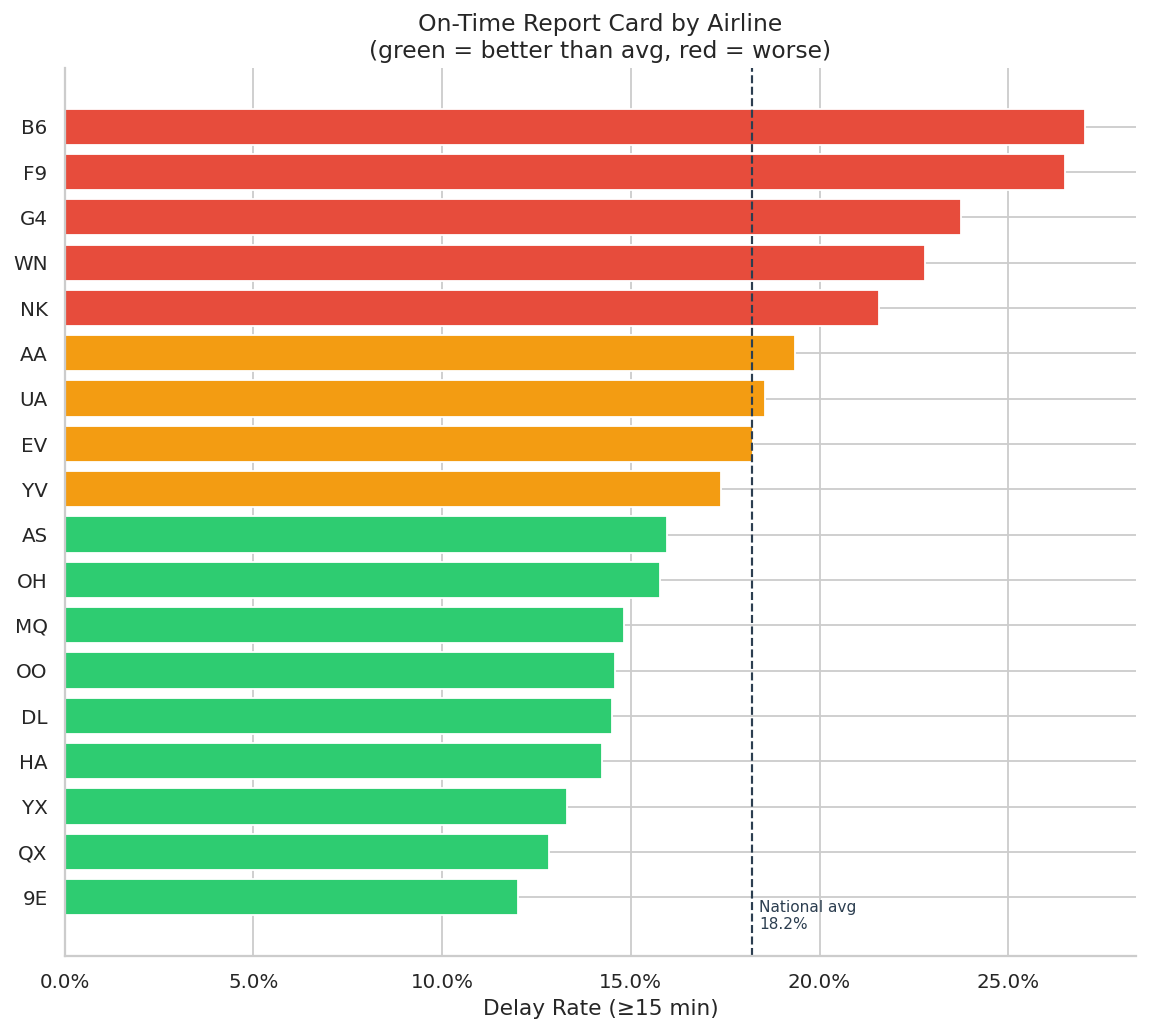

In [ ]:
# ── Aggregate by airline
airline_agg = (
    df.groupby(CARRIER_COL)
    .agg(delay_rate=('IS_DELAYED', 'mean'), count=('IS_DELAYED', 'count'))
    .query('count > 1000')
    .sort_values('delay_rate')
    .reset_index()
)
nat_avg = df['IS_DELAYED'].mean()
airline_agg['vs_avg'] = airline_agg['delay_rate'] - nat_avg
airline_agg['color']  = airline_agg['vs_avg'].apply(
    lambda x: '#2ecc71' if x < -0.02 else ('#e74c3c' if x > 0.02 else '#f39c12')
)

fig, ax = plt.subplots(figsize=(9, max(4, len(airline_agg) * 0.45)))
ax.barh(airline_agg[CARRIER_COL], airline_agg['delay_rate'],
        color=airline_agg['color'], edgecolor='white')

ax.axvline(nat_avg, color='#2c3e50', linestyle='--', linewidth=1.2)
ax.text(nat_avg + 0.002, -0.7, f'National avg\n{nat_avg:.1%}',
        fontsize=8.5, color='#2c3e50')

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('On-Time Report Card by Airline\n(green = better than avg, red = worse)', fontsize=13)
ax.set_xlabel('Delay Rate (≥15 min)')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
print(airline_agg.round(3))

   AIRLINE_CODE  delay_rate   count  vs_avg    color
0            9E       0.120  110140  -0.062  #2ecc71
1            QX       0.128   20284  -0.054  #2ecc71
2            YX       0.133  138611  -0.049  #2ecc71
3            HA       0.142   31730  -0.040  #2ecc71
4            DL       0.145  389339  -0.037  #2ecc71
5            OO       0.146  336153  -0.036  #2ecc71
6            MQ       0.148  117758  -0.034  #2ecc71
7            OH       0.158  103854  -0.024  #2ecc71
8            AS       0.160   98616  -0.022  #2ecc71
9            YV       0.174   62686  -0.008  #f39c12
10           EV       0.182   18028   0.001  #f39c12
11           UA       0.186  249083   0.004  #f39c12
12           AA       0.193  372441   0.011  #f39c12
13           NK       0.216   93433   0.034  #e74c3c
14           WN       0.228  557105   0.046  #e74c3c
15           G4       0.237   50367   0.055  #e74c3c
16           F9       0.265   62846   0.083  #e74c3c
17           B6       0.270  109882   0.088  #

Below are the corresponding names for each carrier.
| Code | Airline |
|------|---------|
| 9E | Endeavor Air |
| AA | American Airlines |
| AS | Alaska Airlines |
| B6 | JetBlue Airways |
| DL | Delta Air Lines |
| EV | ExpressJet Airlines |
| F9 | Frontier Airlines |
| G4 | Allegiant Air |
| HA | Hawaiian Airlines |
| MQ | Envoy Air (American Eagle) |
| NK | Spirit Airlines |
| OH | PSA Airlines |
| OO | SkyWest Airlines |
| QX | Horizon Air |
| UA | United Airlines |
| WN | Southwest Airlines |
| YV | Mesa Airlines |
| YX | Republic Airways |

#### Observations: Delay Rate by Airline
**Top 5 Delayed Carriers**
1. JetBlue Airways
2. Frontier Airlines
3. Allegiant Air
4. Southwest Airlines
5. Spirit Airlines

Despite being smaller carriers, they are fully independent. They are considered *low cost* or *ultra low cost* carriers. Their delay patterns reflect their own operational decisions, like aggressive turnaround times and high aircraft utilization, which ironically can make them more susceptible to the domino effect we identified in the hour-of-day chart, not less.

When it comes to flying, maybe you really do get what you pay for 💸.

### 4.2 Delay Rate vs. Flight Distance  *(Altair)*
**Chart type:** Altair scatter plot with trend line  
**Why this chart:** A scatter plot is the right tool for exploring a relationship between two continuous variables.

In [ ]:
if DISTANCE_COL in df.columns:
    df['DIST_BUCKET'] = pd.cut(df[DISTANCE_COL], bins=20)
    dist_agg = (
        df.groupby(['DIST_BUCKET', CARRIER_COL], observed=True)
        .agg(delay_rate=('IS_DELAYED','mean'), count=('IS_DELAYED','count'))
        .query('count > 100')
        .reset_index()
    )
    dist_agg['dist_mid'] = dist_agg['DIST_BUCKET'].apply(lambda x: x.mid)
    dist_agg = dist_agg.drop(columns=['DIST_BUCKET'])  # ← drop the Interval column

    base = alt.Chart(dist_agg)

    scatter = base.mark_circle(opacity=0.5, size=35).encode(
        x=alt.X('dist_mid:Q',   axis=alt.Axis(title='Flight Distance (miles)')),
        y=alt.Y('delay_rate:Q', axis=alt.Axis(format='%', title='Delay Rate')),
        color=alt.Color(f'{CARRIER_COL}:N', scale=alt.Scale(scheme='tableau10'),
                        legend=alt.Legend(title='Airline')),
        size=alt.Size('count:Q', legend=None),
        tooltip=[
            alt.Tooltip(f'{CARRIER_COL}:N', title='Airline'),
            alt.Tooltip('dist_mid:Q',       title='Approx Distance (mi)', format='.0f'),
            alt.Tooltip('delay_rate:Q',     title='Delay Rate', format='.1%'),
            alt.Tooltip('count:Q',          title='Flights')
        ]
    )

    trend = base.transform_regression(
        'dist_mid', 'delay_rate'
    ).mark_line(
        color='#1F4E79', strokeWidth=2.5, strokeDash=[6, 3]
    ).encode(
        x='dist_mid:Q',
        y='delay_rate:Q'
    )

    chart_dist = (
        (scatter + trend)
        .properties(
            title='Delay Rate vs. Flight Distance by Airline',
            width=680, height=320
        )
        .configure_title(fontSize=15, anchor='start')
        .configure_axis(labelFontSize=11, titleFontSize=12)
        .interactive()
    )

    display(chart_dist)
else:
    print(f'{DISTANCE_COL} column not found — update DISTANCE_COL above.')

alt.LayerChart(...)

#### Observations: Delay Rate vs. Flight Distance by Airline
**Note**: the choice was made to bin the median distances to reduce the insane amount of clutter without binning. I will provide an unbinned chart below to demonstrate why.

In this scatterplot, we are simply looking for a relationship between delay rate and flight distance in a route. The illustrated trend line shows a very weak positive relationship with the two. This informs us that flight distance is not a strong indicator for delays.

In [ ]:
if DISTANCE_COL in df.columns:

    # ── Aggregate at route level instead of distance buckets ───────────────
    # Each point = one airline's average on a specific distance rounded to
    # the nearest 50 miles — gives natural spread along the x-axis
    dist_agg = (
        df.groupby([CARRIER_COL, DISTANCE_COL], observed=True)
        .agg(delay_rate=('IS_DELAYED', 'mean'), count=('IS_DELAYED', 'count'))
        .query('count > 50')
        .reset_index()
    )

    # Round distance to nearest 50mi to reduce overplotting while keeping spread
    dist_agg['dist_rounded'] = (dist_agg[DISTANCE_COL] / 50).round() * 50

    base = alt.Chart(dist_agg)

    scatter = base.mark_circle(opacity=0.4, size=25).encode(
        x=alt.X('dist_rounded:Q', axis=alt.Axis(title='Flight Distance (miles)')),
        y=alt.Y('delay_rate:Q',   axis=alt.Axis(format='%', title='Delay Rate')),
        color=alt.Color(f'{CARRIER_COL}:N', scale=alt.Scale(scheme='tableau10'),
                        legend=alt.Legend(title='Airline')),
        tooltip=[
            alt.Tooltip(f'{CARRIER_COL}:N', title='Airline'),
            alt.Tooltip('dist_rounded:Q',   title='Distance (mi)', format='.0f'),
            alt.Tooltip('delay_rate:Q',     title='Delay Rate', format='.1%'),
            alt.Tooltip('count:Q',          title='Flights')
        ]
    )

    trend = base.transform_regression(
        'dist_rounded', 'delay_rate'
    ).mark_line(
        color='#1F4E79', strokeWidth=2.5, strokeDash=[6, 3]
    ).encode(
        x='dist_rounded:Q',
        y='delay_rate:Q'
    )

    chart_dist = (
        (scatter + trend)
        .properties(
            title='Delay Rate vs. Flight Distance by Airline (without binning)',
            width=680, height=320
        )
        .configure_title(fontSize=15, anchor='start')
        .configure_axis(labelFontSize=11, titleFontSize=12)
        .interactive()
    )

    display(chart_dist)

alt.LayerChart(...)

### 4.3 Distribution of Delay Length by Airline — Box Plot
**Chart type:** Seaborn box plot  
**Why this chart:** A bar chart can only show the average — a box plot reveals spread, skew, and outliers. Some airlines may delay *less often* but delay *far longer* when they do, which a simple average would hide.

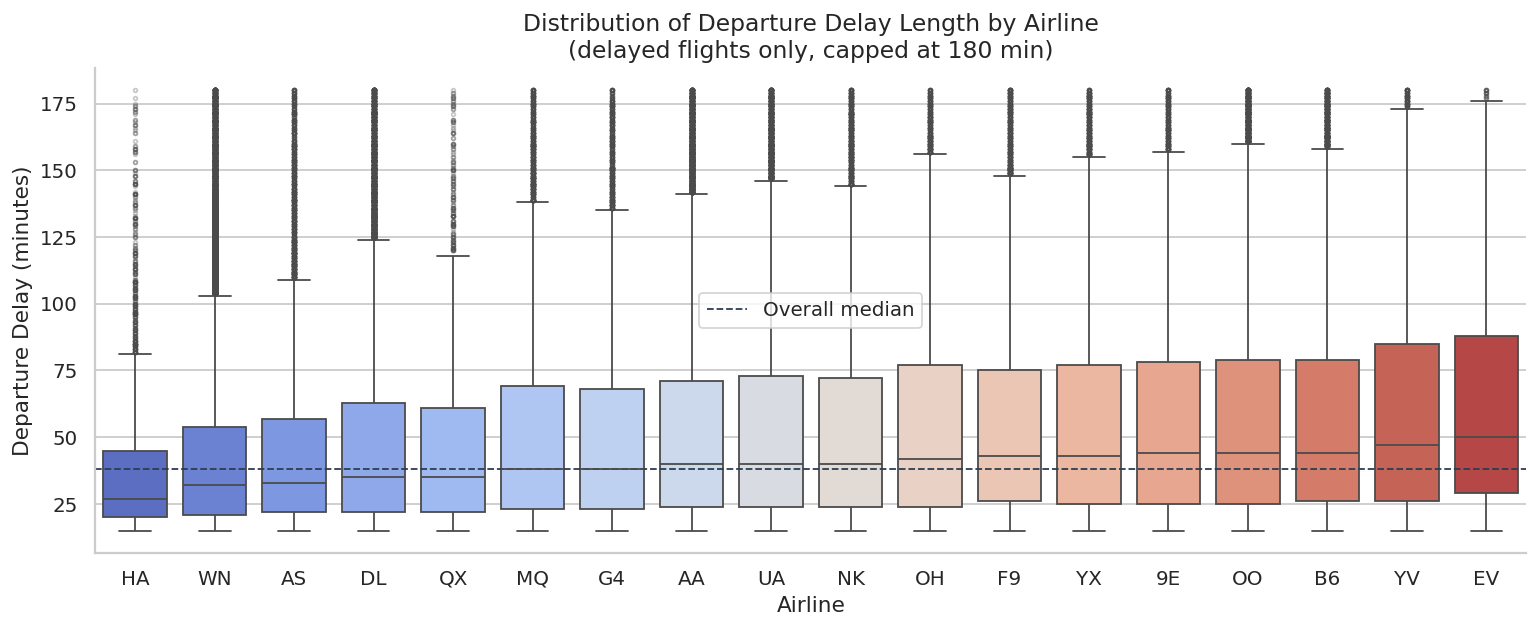

In [ ]:
# ── Filter to delayed flights only, cap extreme outliers for readability ───
df_box = df[(df['IS_DELAYED'] == 1) & (df['DEP_DELAY'] <= 180)].copy()

# Rank airlines by median delay for sorted display
airline_order = (
    df_box.groupby(CARRIER_COL)['DEP_DELAY']
    .median()
    .sort_values()
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=df_box,
    x=CARRIER_COL, y='DEP_DELAY',
    order=airline_order,
    palette=sns.color_palette('coolwarm', len(airline_order)),
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax
)

ax.set_title('Distribution of Departure Delay Length by Airline\n(delayed flights only, capped at 180 min)', fontsize=13)
ax.set_xlabel('Airline')
ax.set_ylabel('Departure Delay (minutes)')
ax.axhline(df_box['DEP_DELAY'].median(), color='#2c3e50',
           linestyle='--', linewidth=1, label=f'Overall median')
ax.legend()
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

Below are the corresponding names for each carrier.
| Code | Airline |
|------|---------|
| 9E | Endeavor Air |
| AA | American Airlines |
| AS | Alaska Airlines |
| B6 | JetBlue Airways |
| DL | Delta Air Lines |
| EV | ExpressJet Airlines |
| F9 | Frontier Airlines |
| G4 | Allegiant Air |
| HA | Hawaiian Airlines |
| MQ | Envoy Air (American Eagle) |
| NK | Spirit Airlines |
| OH | PSA Airlines |
| OO | SkyWest Airlines |
| QX | Horizon Air |
| UA | United Airlines |
| WN | Southwest Airlines |
| YV | Mesa Airlines |
| YX | Republic Airways |

#### Observations: Distribution of Delay Length by Airline
Airlines are sorted by their median delay (the line inside the box), so left = best, right = worst.

* HA (Hawaiian) — the best performer. Tight box sitting low, meaning when Hawaiian delays you, it's typically a short delay and very consistent
* WN (Southwest) and AS (Alaska) — also tight boxes, reliable even when delayed
* EV (ExpressJet) and YV (Mesa) — rightmost and worst. Wide boxes sitting high means they delay longer and less predictably
* The dashed line is the overall median across every airline — airlines whose median line sits above it are worse than average, below it are better.

Most airlines have a similar median (the internal line hovers near the dashed overall median around 38 min), but what separates the good from the bad is box height — the spread. EV and YV don't just delay longer on average, they're far less consistent, meaning a delayed flight on those carriers is a bigger gamble on how long you'll actually wait.

### Chapter 4 Summary
Not all airlines are created equal when it comes to delays — and the data suggests that price may be a reasonable proxy for punctuality. The five worst-performing carriers by delay rate are JetBlue, Frontier, Allegiant, Southwest, and Spirit, all of which are fully independent low-cost or ultra-low-cost carriers. Their elevated delay rates are not a coincidence — the same aggressive turnaround times and high aircraft utilization that keep ticket prices low also leave zero buffer in the schedule when something goes wrong, making them disproportionately vulnerable to the compounding domino effect identified in Chapter 1. When it comes to flying, you may get what you pay for.
Flight distance, by contrast, turns out to be a poor predictor of delay risk. The scatter plot reveals only a very weak positive relationship between route distance and delay rate, meaning whether you're flying a short regional hop or a cross-country haul, your odds of being delayed are driven far more by the airline you chose and the time you depart than by how far you're going.
Where the carriers diverge most sharply is not in how often they delay, but in how long those delays last and how consistent they are. Most airlines cluster near the same overall median of roughly 38 minutes — but the spread of that box tells a very different story airline by airline. Hawaiian (HA) is the standout best performer, with a tight, low distribution indicating short and predictable delays when they occur. Alaska (AS) and Southwest (WN) follow closely. At the other end, ExpressJet (EV) and Mesa (YV) are not only the worst median performers but the most unpredictable — a delayed flight on either carrier is a genuine gamble on how long you will actually be waiting at the gate.

---
## 5. Key Takeaways

**1. Timing is everything.**  
* Fly early in the morning. Delays have a domino effect throughout the day, so at 0500 you are less likely to run into any problems.
* The day of the week as a minimal impact on delay rates. Friday and Sunday are have the highest rates. This is probably because of increased travel volume at the start and end of the weekend.

**2. COVID reset the system — and revealed what "normal" really means.**
* COVID-19 shocked the system. In 2020, delay rates dropped to crazy lows until mid-2021 then travel picked back up. In 2022, we see rates similar to 2019. This is aa soft confirmation of what "normal" is.

**3. Not all delay causes are equal.**  
* Controllable delays like carrier issues and late aircraft dominate delay causes. Uncontrollable factors like weather and security incidents are significantly less common by comparison.

**4. Geography shapes delay risk.**  
* Though Chicago Midway was the most delayed airport in the country. However, there doesn't seem to be a clear geographical pattern to delay rates. Most of the airports in the US are located on the East Coast, so that's where we see most of the delays. This isn't enough evidence to say the two are correlated.
* There may be some value in looking into how a region's weather patterns affect the delay rate. I notice that the areas with higher concentrations of delays are places that are prone to either winter storms or Florida where tropical storms are prevailent.

**5. Airline choice matters more than most travelers realize.**  
* You get what you pay for. The low cost and ultra low cost carriers were found to have the highest delay rates of all the carriers.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── Strip broken widget metadata before converting ─────────────────────────
import nbformat
import json

notebook_path = '/content/drive/MyDrive/Colab Notebooks/DASC 5231 - Data Visualization/Final Project/flight_delay_dataviz.ipynb'

with open(notebook_path, 'r') as f:
    nb = nbformat.read(f, as_version=4)

# Remove broken widget state from notebook metadata
if 'widgets' in nb.metadata:
    del nb.metadata['widgets']

# Remove broken widget state from individual cell outputs
for cell in nb.cells:
    if hasattr(cell, 'outputs'):
        for output in cell.outputs:
            if 'metadata' in output and 'widgets' in output.get('metadata', {}):
                del output['metadata']['widgets']

# Save cleaned notebook
cleaned_path = notebook_path.replace('.ipynb', '_cleaned.ipynb')
with open(cleaned_path, 'w') as f:
    nbformat.write(nb, f)

print(f'Cleaned notebook saved to: {cleaned_path}')

Cleaned notebook saved to: /content/drive/MyDrive/Colab Notebooks/DASC 5231 - Data Visualization/Final Project/flight_delay_dataviz_cleaned.ipynb


In [ ]:
!jupyter nbconvert "/content/drive/MyDrive/Colab Notebooks/DASC 5231 - Data Visualization/Final Project/flight_delay_dataviz_cleaned.ipynb" --to html

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/DASC 5231 - Data Visualization/Final Project/flight_delay_dataviz_cleaned.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 8 image(s).
[NbConvertApp] Writing 1879212 bytes to /content/drive/MyDrive/Colab Notebooks/DASC 5231 - Data Visualization/Final Project/flight_delay_dataviz_cleaned.html
